In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra
using DifferentialEquations, StaticArrays

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [10]:
crypts_all = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :active => Bool,

        :S_o => Float64,
        :S_r => Float64,
        :S_s => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64,
        :M => Float64
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium_o => Float64,
        :DMedium_r => Float64,
        :DMedium_s => Float64,
        :delta_o => Float64,
        :delta_r => Float64,
        :delta_s => Float64
    ),

    medium = Dict(
        :mm_o => Float64,
        :mm_r => Float64,
        :mm_s => Float64,
        :ve => Float64
    ),

    agentODE = quote
  
        xmin, xmax = simBox[1,1], simBox[1,2]
        ymin, ymax = simBox[2,1], simBox[2,2]


        idx = Int(floor(Int, x/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        idy = Int(floor(Int, y/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        
        # X direction
        if x < xmin
            idx = Int(floor(Int, (x+(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)

        elseif x > xmax
            idx = Int(floor(Int, (x-(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)

        end

        # # Y direction
        if y < ymin
            idy = Int(floor(Int,(y+ymax-ymin)/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)

        elseif y > ymax
            idy = Int(floor(Int,(y-(ymax-ymin))/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)

        end

        mmo = max(0, mm_o[idx,idy])     # Oxygent concentration
        mmr = max(0, mm_r[idx,idy])     # Repellant concentration
        mms = max(0, mm_s[idx,idy])     # Self concentration

        F = ε0 + ε1 * methyl + Nrec * log((1 + mmo / Ki) / (1 + mmo / Ka)) - Nrec * log((1 + mmr / Ki) / (1 + mmr / Ka)) + Nrec * log((1 + mms / Ki) / (1 + mms / Ka))
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)      

        mx = (ε0 + Nrec * log((1 + mmo / Ki) / (1 + mmo / Ka)) - Nrec * log((1 + mmr / Ki) / (1 + mmr / Ka)) + Nrec * log((1 + mms / Ki) / (1 + mms / Ka)) - F0) / (- ε1)
       

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))     

        dt(x) = vx 
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)     
        
    end,

    agentRule = quote

        xmin, xmax = simBox[1,1], simBox[1,2]
        ymin, ymax = simBox[2,1], simBox[2,2]

        idx = Int(floor(Int, x/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        idy = Int(floor(Int, y/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)        
       
     # Adding population every 100 steps
        p_add = 0.005

        if i1_ == 1
            for k in 1:10
                if rand() < p_add
                    @addAgent(
                        x = xmin + 10,
                        y = ymax/2 + 10 + rand()*(ymax - (ymax/2) - 10),
                        theta = 2 * pi,
                        l = 3
                    )
                end
            end
        end

        v_run = v
        v_tumble = 0.25 
        speed = active ? v_run : v_tumble

        Dr_tumble = 6.2      
        Dr_total = active ? Dr_run : Dr_tumble

        mm_s[idx,idy] += S_s

        if active 
            λ = ωFrec*exp(-G)
            P = 1 - exp(-λ * dt)
                
        else
            λ = ωFrec*exp(G)
            P = 1 - exp(-λ * dt)  
                
        end

        x_idx = clamp(round(Int, x/2), 1, x2/2)
        y_idx = clamp(round(Int, y/2), 1, x2/2)

        if active 
            λrt = ωFrec*exp(-G) 
            P_rt = 1 - exp(-λrt * dt)
            P = rand() 
                                                  
            if P < P_rt             
                active = false
                vx = speed* cos(theta) + ve[idx, idy]
                vy = speed* sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn() 
                        
            else    
                active = true
                vx = speed * cos(theta) + ve[idx, idy]
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
                     
            end

        else
            λtr = ωFrec*exp(G) 
            P_tr = 1 - exp(-λtr * dt)
            P = rand()

            if P < P_tr
                active = true
                vx = speed * cos(theta) + ve[idx, idy]
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()

            else
                active = false
                vx = speed* cos(theta) + ve[idx, idy]
                vy = speed* sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()

            end
        end

        if x <= xmin
            x = xmin + (xmin - x)
            theta = pi - theta
        elseif x >= xmax
            @removeAgent()
        end

        if y >= 750
            y = 2*750 - y
            theta = 2*pi - theta
        end

        if y <= wall_y(x, width, depth, y_start, 20, y2)
            x_new = clamp(round(Int, x/2), 1, 500)
            y_new = clamp(round(Int, y/2), 1, 500)

            if MYT[x_new, y_new] == 1 && MXR[x_new, y_new] == 1
                y = wall_y(x, width, depth, y_start, 20, y2) + 1
                x = x + 1
                theta = theta + pi

            elseif MYT[x_new, y_new] == 1 && MXL[x_new, y_new] == 1
                y = wall_y(x, width, depth, y_start, 20, y2) + 1
                x = x - 1
                theta = theta + pi

            elseif MYT[x_new, y_new] == 1 
                y = wall_y(x, width, depth, y_start, 20, y2) + 1
                theta = 2*pi - theta

            elseif MXR[x_new, y_new] == 1
                x = x + 2
                theta = pi - theta

            elseif MXL[x_new, y_new] == 1
                x = x - 2
                theta = pi - theta

            elseif M0[x_new, y_new] == 1        # Esta dins, no pinta res allí
                t0 = round(Int, (t-1))
                x_old = x[t0]
                y_old = y[t0]
                nsteps = ceil(Int, max(abs(x - x_old), abs(y - y_old)))

                hit_type = nothing

                for s in 0:nsteps
                    xs = x_old + (x - x_old) * s / nsteps
                    ys = y_old + (y - y_old) * s / nsteps

                    xi = clamp(round(Int, xs/2), 1, 500)
                    yi = clamp(round(Int, ys/2), 1, 500)

                    if MXR[xi, yi]
                        hit_type = :right
                        break
                    elseif MXL[xi, yi]
                        hit_type = :left
                        break
                    elseif MYT[xi, yi]
                        hit_type = :horizontal
                        break
                    end
                end
                if hit_type == :right
                    x = x_old
                    theta = pi - theta

                elseif hit_type == :left
                    x = x_old
                    theta = pi - theta

                elseif hit_type == :horizontal
                    y = y_old
                    theta = 2*pi - theta
                end
                                
            end
        end
    end,


    mediumODE = quote

        if @mediumInside()
    # --- geometry mask FIRST (do NOT overwrite mm_s itself) ---
            if M0[i1_, i2_]
                dt(mm_o) = 0
                dt(mm_r) = 0
                dt(mm_s) = 0

            elseif MB[i1_, i2_]
                dt(mm_o) = 0
                dt(mm_r) = 0
                dt(mm_s) = 0

            else
                dt(mm_o) = DMedium_o * (@∂2(1, mm_o) + @∂2(2, mm_o)) - delta_o * mm_o - ve[i1_, i2_] * @∂(1, mm_o)
                dt(mm_r) = DMedium_r * (@∂2(1, mm_r) + @∂2(2, mm_r)) - delta_r * mm_r - ve[i1_, i2_] * @∂(1, mm_r)
                dt(mm_s) = DMedium_s * (@∂2(1, mm_s) + @∂2(2, mm_s)) - delta_s * mm_s - ve[i1_, i2_] * @∂(1, mm_s)

            end
     
            mm_o = MXR[i1_, i2_] ? S_o : mm_o
            mm_o = MXL[i1_, i2_] ? S_o : mm_o
            mm_o = MYT[i1_, i2_] ? S_o : mm_o
            mm_o = MB[i1_, i2_ + 1] ? mm_o[i1_, i2_ - 1] : mm_o

            mm_r = MXR[i1_, i2_] ? S_r : mm_r
            mm_r = MXL[i1_, i2_] ? S_r : mm_r
            mm_r = MYT[i1_, i2_] ? S_r : mm_r
            mm_r = MB[i1_, i2_ + 1] ? mm_r[i1_, i2_ - 1] : mm_r
            
            mm_s = MXR[i1_, i2_] ? mm_s[i1_ + 1, i2_] : mm_s
            mm_s = MXL[i1_, i2_] ? mm_s[i1_ - 1, i2_] : mm_s
            mm_s = MYT[i1_, i2_] ? mm_s[i1_, i2_ + 1] : mm_s
            mm_s = MB[i1_, i2_ + 1] ? mm_s[i1_, i2_ - 1] : mm_s


        elseif @mediumBorder(1,-1) # left PBC
            mm_o = mm_o[1, i2_]
            mm_r = mm_r[1, i2_]
            mm_s = mm_s[1, i2_]

        elseif @mediumBorder(1,1) #right PBC
            mm_o = mm_o[NMedium[1] - 1, i2_]
            mm_r = mm_r[NMedium[1] - 1, i2_]
            mm_s = mm_s[NMedium[1] - 1, i2_]

        elseif @mediumBorder(2,-1) # down NBC (newmann)
            mm_o = 0
            mm_r = 0
            mm_s = 0

        elseif @mediumBorder(2,+1)
            mm_o = 0
            mm_r = 0
            mm_s = 0

        end
    end,


    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler()
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	xₘ (Float64 medium)
	yₘ (Float64 medium)
	S_r (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	active (Bool agent)
	v (Float64 agent)
	λ (Float64 agent)
	S_o (Float64 agent)
	F (Float64 agent)
	A (Float64 agent)
	methyl (Float64 agent)
	vx (Float64 agent)
	l (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	G (Float64 agent)
	vy (Float64 agent)
	theta (Float64 agent)
	S_s (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	DMedium_r (Float64 model)
	Ka (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	Nrec (Float64 model)
	τm (Float64 model)
	DMedium_s (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	delta_s (Float64 model)
	DMedium_o (Float64 model)
	delta_r (Float64 model)
	delta_o (Float64 model)
	ε2 (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)
	ve (Float64 medium)
	mm_o (Float64 medium)
	m

In [2]:
function wall_y(x, w, d, y0, xstart, xend)
    
    # outside wall region → flat at baseline
    if x < xstart || x > xend
        return y0
    end

    # shift x so pattern starts at xstart
    ξ = x - xstart

    # square-wave pattern (0 or -d), then shift up by y0
    return y0 - d * floor((1 + sign(sin(2π * ξ / w))) / 2)
end

wall_y (generic function with 1 method)

In [22]:
x1, x2, y1, y2 = 0, 1000, 0, 1000
med1, med2 = 500, 500

width_1 = 70
depth = 100
y_start = y2/2
x_start = 20
x_end = x2
dx = (x2 - x1) / med1
dy = (y2 -y1) / med2

xcoord(i1_) = x1 + (i1_ - 1) * dx
ycoord(i2_) = y1 + (i2_ - 1) * dy
Nx = med1
Ny = med2

mask_raw = zeros(Bool, med1, med2)
M0 = zeros(Bool, med1, med2)
MXL = zeros(Bool, med1, med2)
MXR = zeros(Bool, med1, med2)
MYT = zeros(Bool, med1, med2)

for i in 1:Nx, j in 1:Ny
    x = xcoord(i)
    y = ycoord(j)
    mask_raw[i,j] = y < wall_y(x, width_1, depth, y_start, x_start, x_end)
end

for i in 2:Nx-1, j in 2:Ny-1
    if mask_raw[i,j] &&
    mask_raw[i+1,j] &&
    mask_raw[i-1,j] &&
    mask_raw[i,j+1] &&
    mask_raw[i,j-1] &&
    mask_raw[i+1,j+1] &&
    mask_raw[i+1,j-1] &&
    mask_raw[i-1,j+1] &&
    mask_raw[i-1,j-1]

        M0[i,j] = true
    end
end

M0[1,   :] .= true
M0[500, :] .= true
M0[1,   250:end] .= false
M0[500, 250:end] .= false
M0[:, 1] .= true

for i in 2:Nx-1, j in 2:Ny-1

    if M0[i,j] == 1

                # --- HORIZONTAL LINES ---
                # bottom edge (neighbor below is outside)
        if M0[i, j-1] == 0
            MYT[i,j] = true
        end

                # top edge (neighbor above is outside)
        if M0[i, j+1] == 0
            MYT[i,j] = true
        end


                # --- LEFT WALL ---
        if M0[i-1, j] == 0
            MXL[i,j] = true
        end


                # --- RIGHT WALL ---
        if M0[i+1, j] == 0
            MXR[i,j] = true
        end

    end
end

MYT[1,   248:249] .= true
MYT[500,   248:249] .= true

MB = zeros(Bool, 500, 500)
MB[:, 375:500] .= true

500×126 view(::Matrix{Bool}, :, 375:500) with eltype Bool:
 1  1  1  1  1  1  1  1  1  1  1  1  1  …  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1     1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1     1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1     1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1     1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  …  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1     1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1     1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1     1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1     1  1  1  1  1  1  1  1  1  1  1  1
 ⋮              ⋮              ⋮        ⋱     ⋮              ⋮              ⋮
 1  1  1  1  1  1  1  1  1  1  1  1  1     1  1  1  1  1  1  1  1  1  1  1  1
 1  1

In [17]:
data = Dict{Int, Any}()
step = 100000
jldopen("c_all_n0.5_lc_100_ve_5.jld2", "r") do file
        key = file[@sprintf("step_%06d", step)]
        data[step] = Dict(
            "mm_grid_o" => copy(key["mm_grid_o"]),
            "mm_grid_r" => copy(key["mm_grid_r"]),
            "mm_grid_s" => copy(key["mm_grid_s"])
        )
end

Dict{String, Matrix{Float64}} with 3 entries:
  "mm_grid_o" => [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 1.04456e-16 0.0; … ; 0.0 0.0 … 0…
  "mm_grid_s" => [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0456883 0.0; … ; 0.0 0.0 … 1.5…
  "mm_grid_r" => [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 9.42677e-57 0.0; … ; 0.0 0.0 … 4…

In [18]:
o2grid = data[step]["mm_grid_o"]
repgrid = data[step]["mm_grid_r"]
attgrid = data[step]["mm_grid_s"]

500×500 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0          0.0          0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0456883    0.0456883    0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0225616    0.0225616    0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0110582    0.0110582    0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.00539076   0.00539076   0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0026163    0.0026163    0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.00126661   0.00126661   0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.000614827  0.000614827  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.00030281   0.00030281   0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.00015406   0.00015406   0.0
 ⋮                        ⋮              ⋱                            
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.000274882  0.000274882  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.000575525  0.000575525  0.0
 0.0  0.0  0.0  

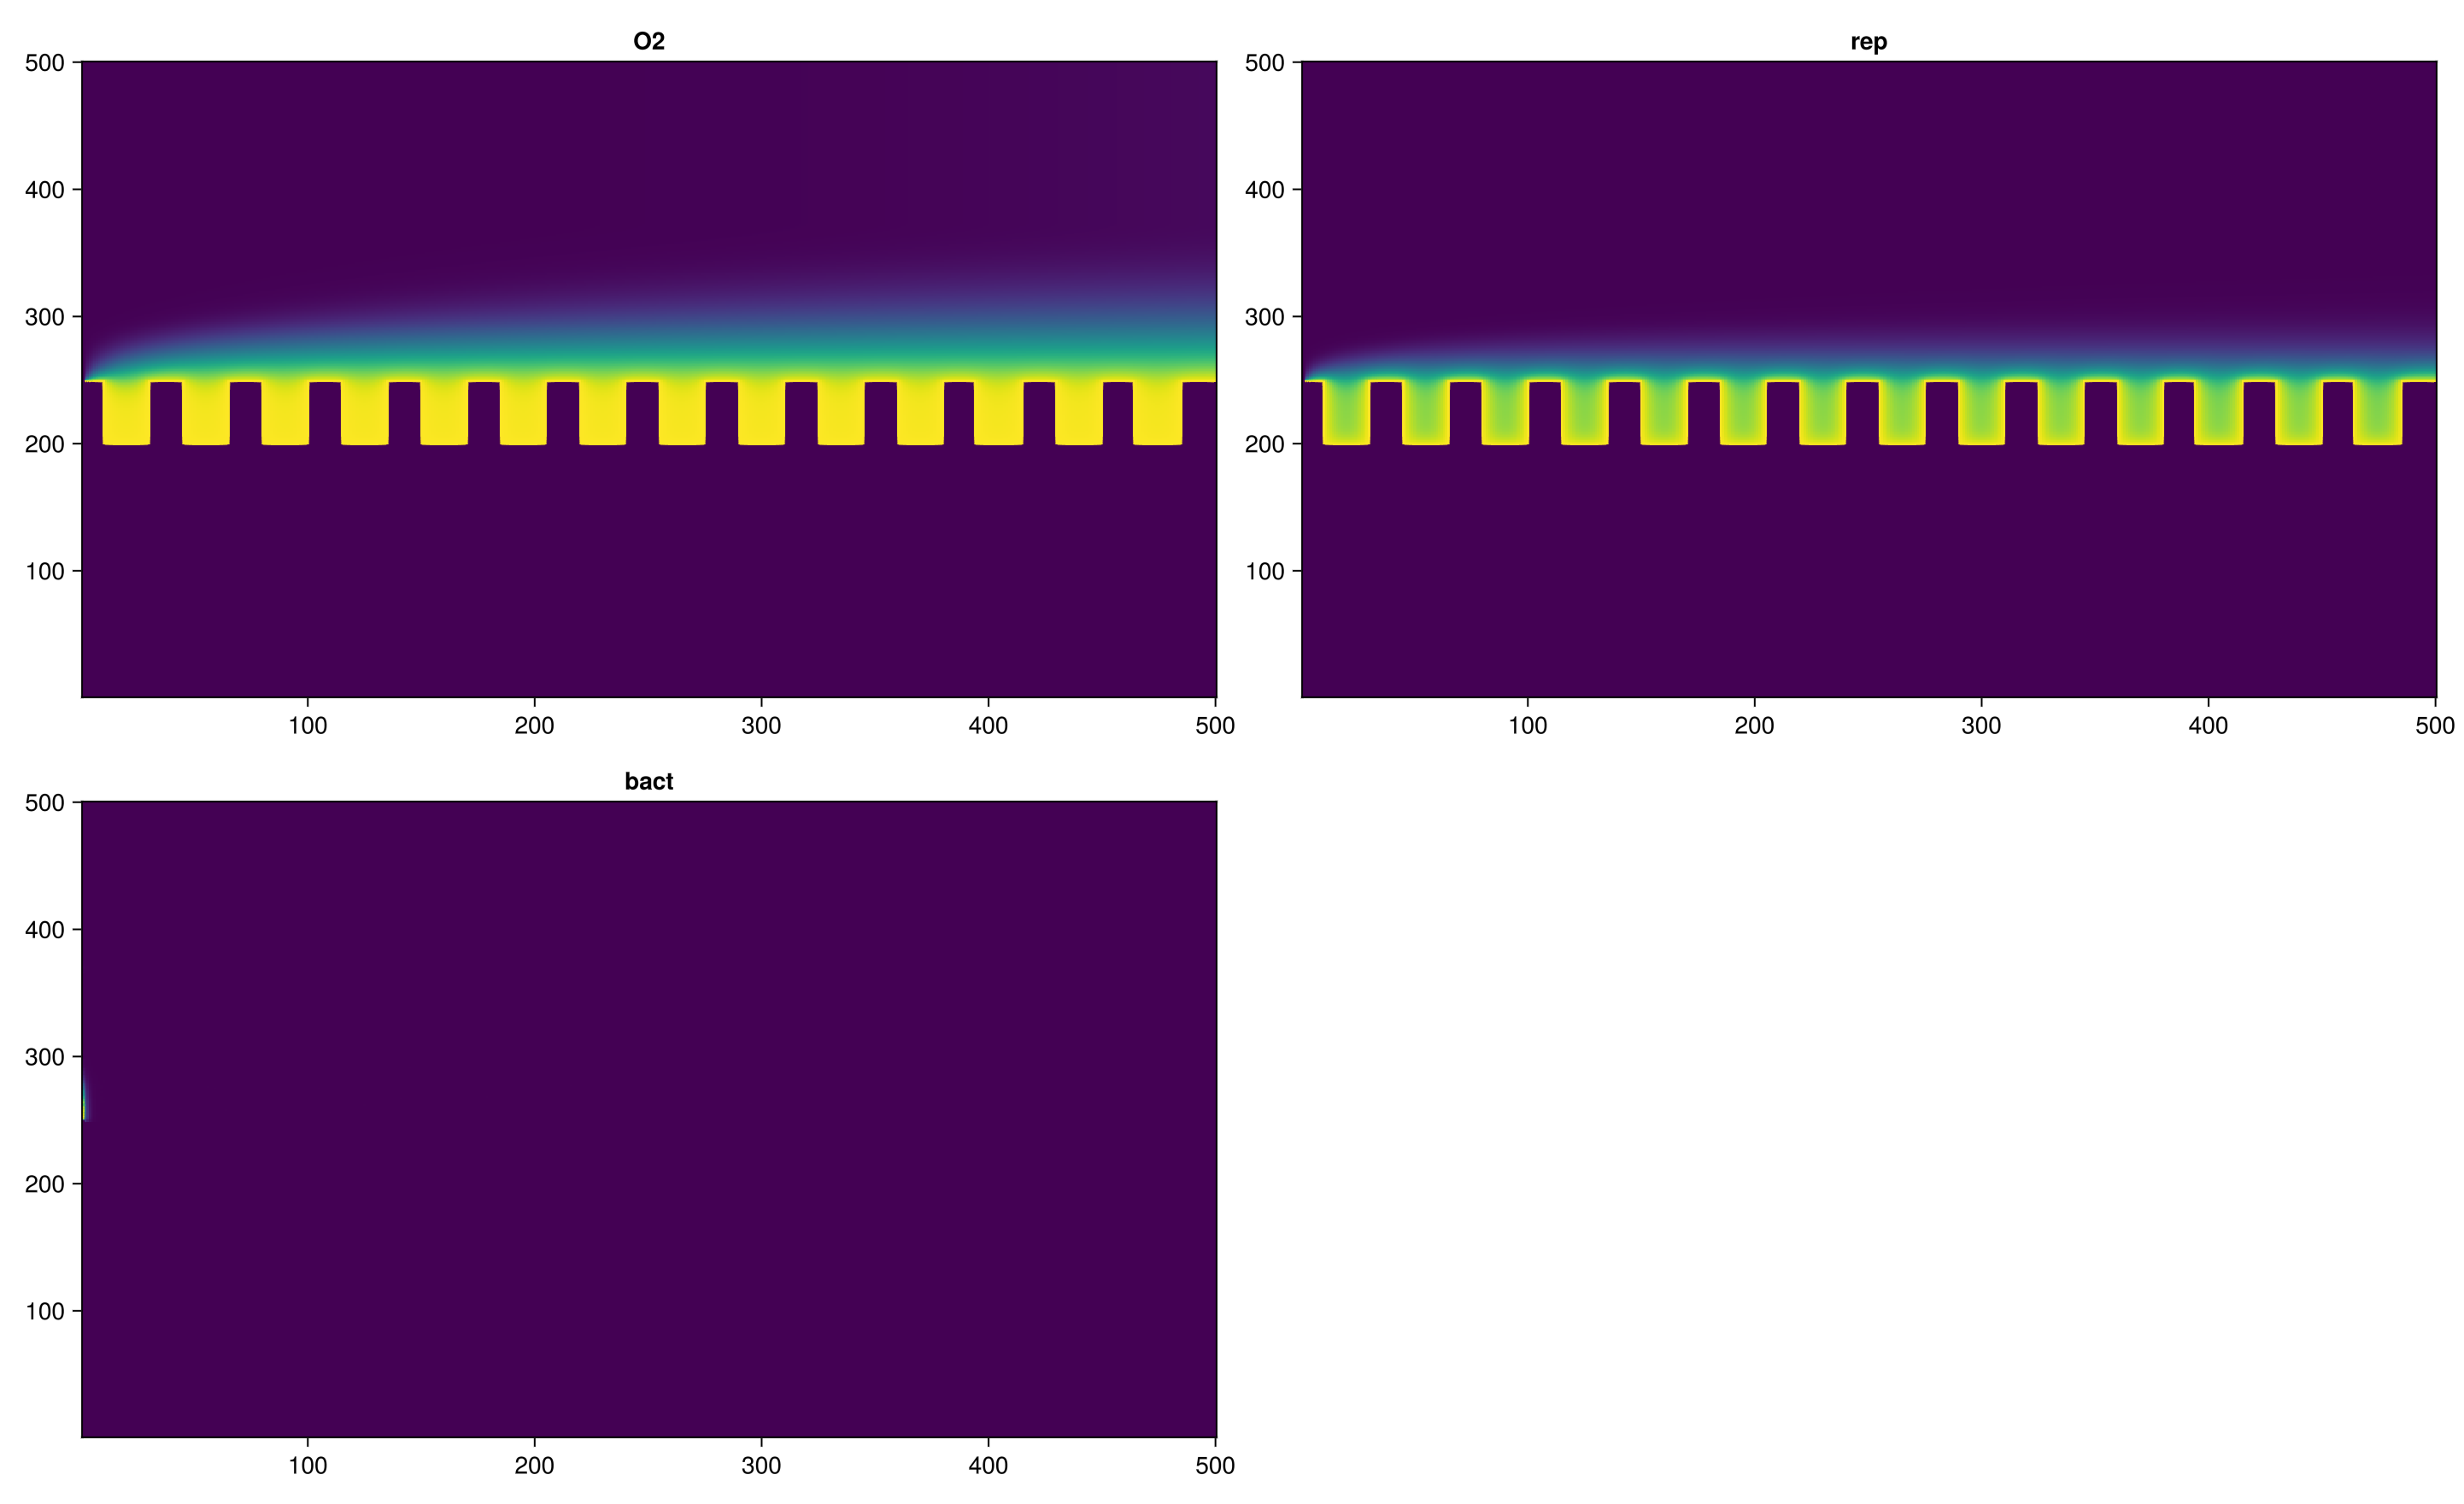

In [19]:
fig = Figure(size = (1800, 1200))
ax1 = Axis(fig[1,1], title = "O2")
ax2 = Axis(fig[1,2], title = "rep")
ax3 = Axis(fig[2,1], title = "bact")

heatmap!(ax1, o2grid)
heatmap!(ax2, repgrid)
heatmap!(ax3, attgrid)

fig

In [10]:
@save "mm_repellant_n2.jld2" repgrid
@save "mm_oxygen_n05.jld2" o2grid

In [6]:
@load "mm_oxygen_n05.jld2" o2grid
@load "mm_repellant_n2.jld2" repgrid

1-element Vector{Symbol}:
 :repgrid

In [23]:
com = Community(
    crypts_all,
    N=1000,
    dt=0.01,
    simBox = [0.0 1000.0; 0.0 1000.0],
    NMedium = [500,500]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

com.v = 20.0    #Velocitat bacteries biològica


com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

com.τm = 1

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

com.DMedium_o = 20
com.DMedium_r = 5
com.DMedium_s = 1.43

com.delta_o = 0.00125
com.delta_r = 0.005
com.delta_s = 0.0175

com.x = zeros(com.N)
com.y = zeros(com.N)

count = 0

while count < com.N
    x_try = rand(Uniform(1, 1000))   ## Limit 750 remember
    y_try = rand(Uniform(1, 750))

    # map to mask indices
    i = Int(floor(x_try / 2)) + 1
    j = Int(floor(y_try / 2)) + 1

    # bounds safety
    if i < 1 || i > y_start || j < 1 || j > y_start
        continue
    end

    if M0[i, j] == 0
        count += 1
        com.x[count] = x_try
        com.y[count] = y_try
    end
end

com.theta = rand(Uniform(0, 2*pi),com.N)

com.methyl .= 0.0
com.Yp .= com.K

com.active .= true 

com.S_o = 0.005
com.S_r = 0.0025
com.S_s = 0.0025

com.ve = zeros(com.NMedium[1], com.NMedium[2])

L = 100.0   # thickness of transition layer (tune this)

for i1 in 1:com.NMedium[1], i2 in 1:com.NMedium[2]
    y = ycoord(i2)

    if y <= y_start
        # Inside crypt → no flow
        com.ve[i1, i2] = 0.0

    elseif y < y_start + L
        # Transition region → smooth increase
        f = (y - y_start) / L
        com.ve[i1, i2] = 10.0 * f^2

    else
        # Bulk lumen → full flow
        com.ve[i1, i2] = 10.0
    end
end
# com.mm_o = mm_grid_o  # Inicialitzar amb gradient ja estable
# com.mm_r = mm_grid_r  # Inicialitzar amb gradient ja estable

In [23]:
outfile = "c_all_box_test.jld2"
steps = 20000

loadToPlatform!(com, preallocateAgents=10000)
# com.mm_o = mm_grid_o  # Inicialitzar amb gradient ja estable
# com.mm_r = mm_grid_r  # Inicialitzar amb gradient ja estable
# com.mm_s = mm_grid_s  # Inicialitzar amb gradient ja estable
com.mm_o = zeros(Float64, com.NMedium...)
com.mm_r = zeros(Float64, com.NMedium...)
com.mm_s = zeros(Float64, com.NMedium...)

jldopen(outfile, "w") do file

    for step in 1:steps
        CellBasedModels.step!(com)
        if step%500 == 0

            stepname = @sprintf("step_%06d", step)
            g = JLD2.Group(file, stepname)

            # Agent-level arrays (length = N)
            g["x"] = copy(com.x)
            g["y"] = copy(com.y)
            g["theta"] = copy(com.theta)

            # Medium grid (saved once per step)
            g["mm_grid_o"] = copy(com.mm_o)
            g["mm_grid_r"] = copy(com.mm_r)
            g["mm_grid_s"] = copy(com.mm_s)
            
        end
    end
end


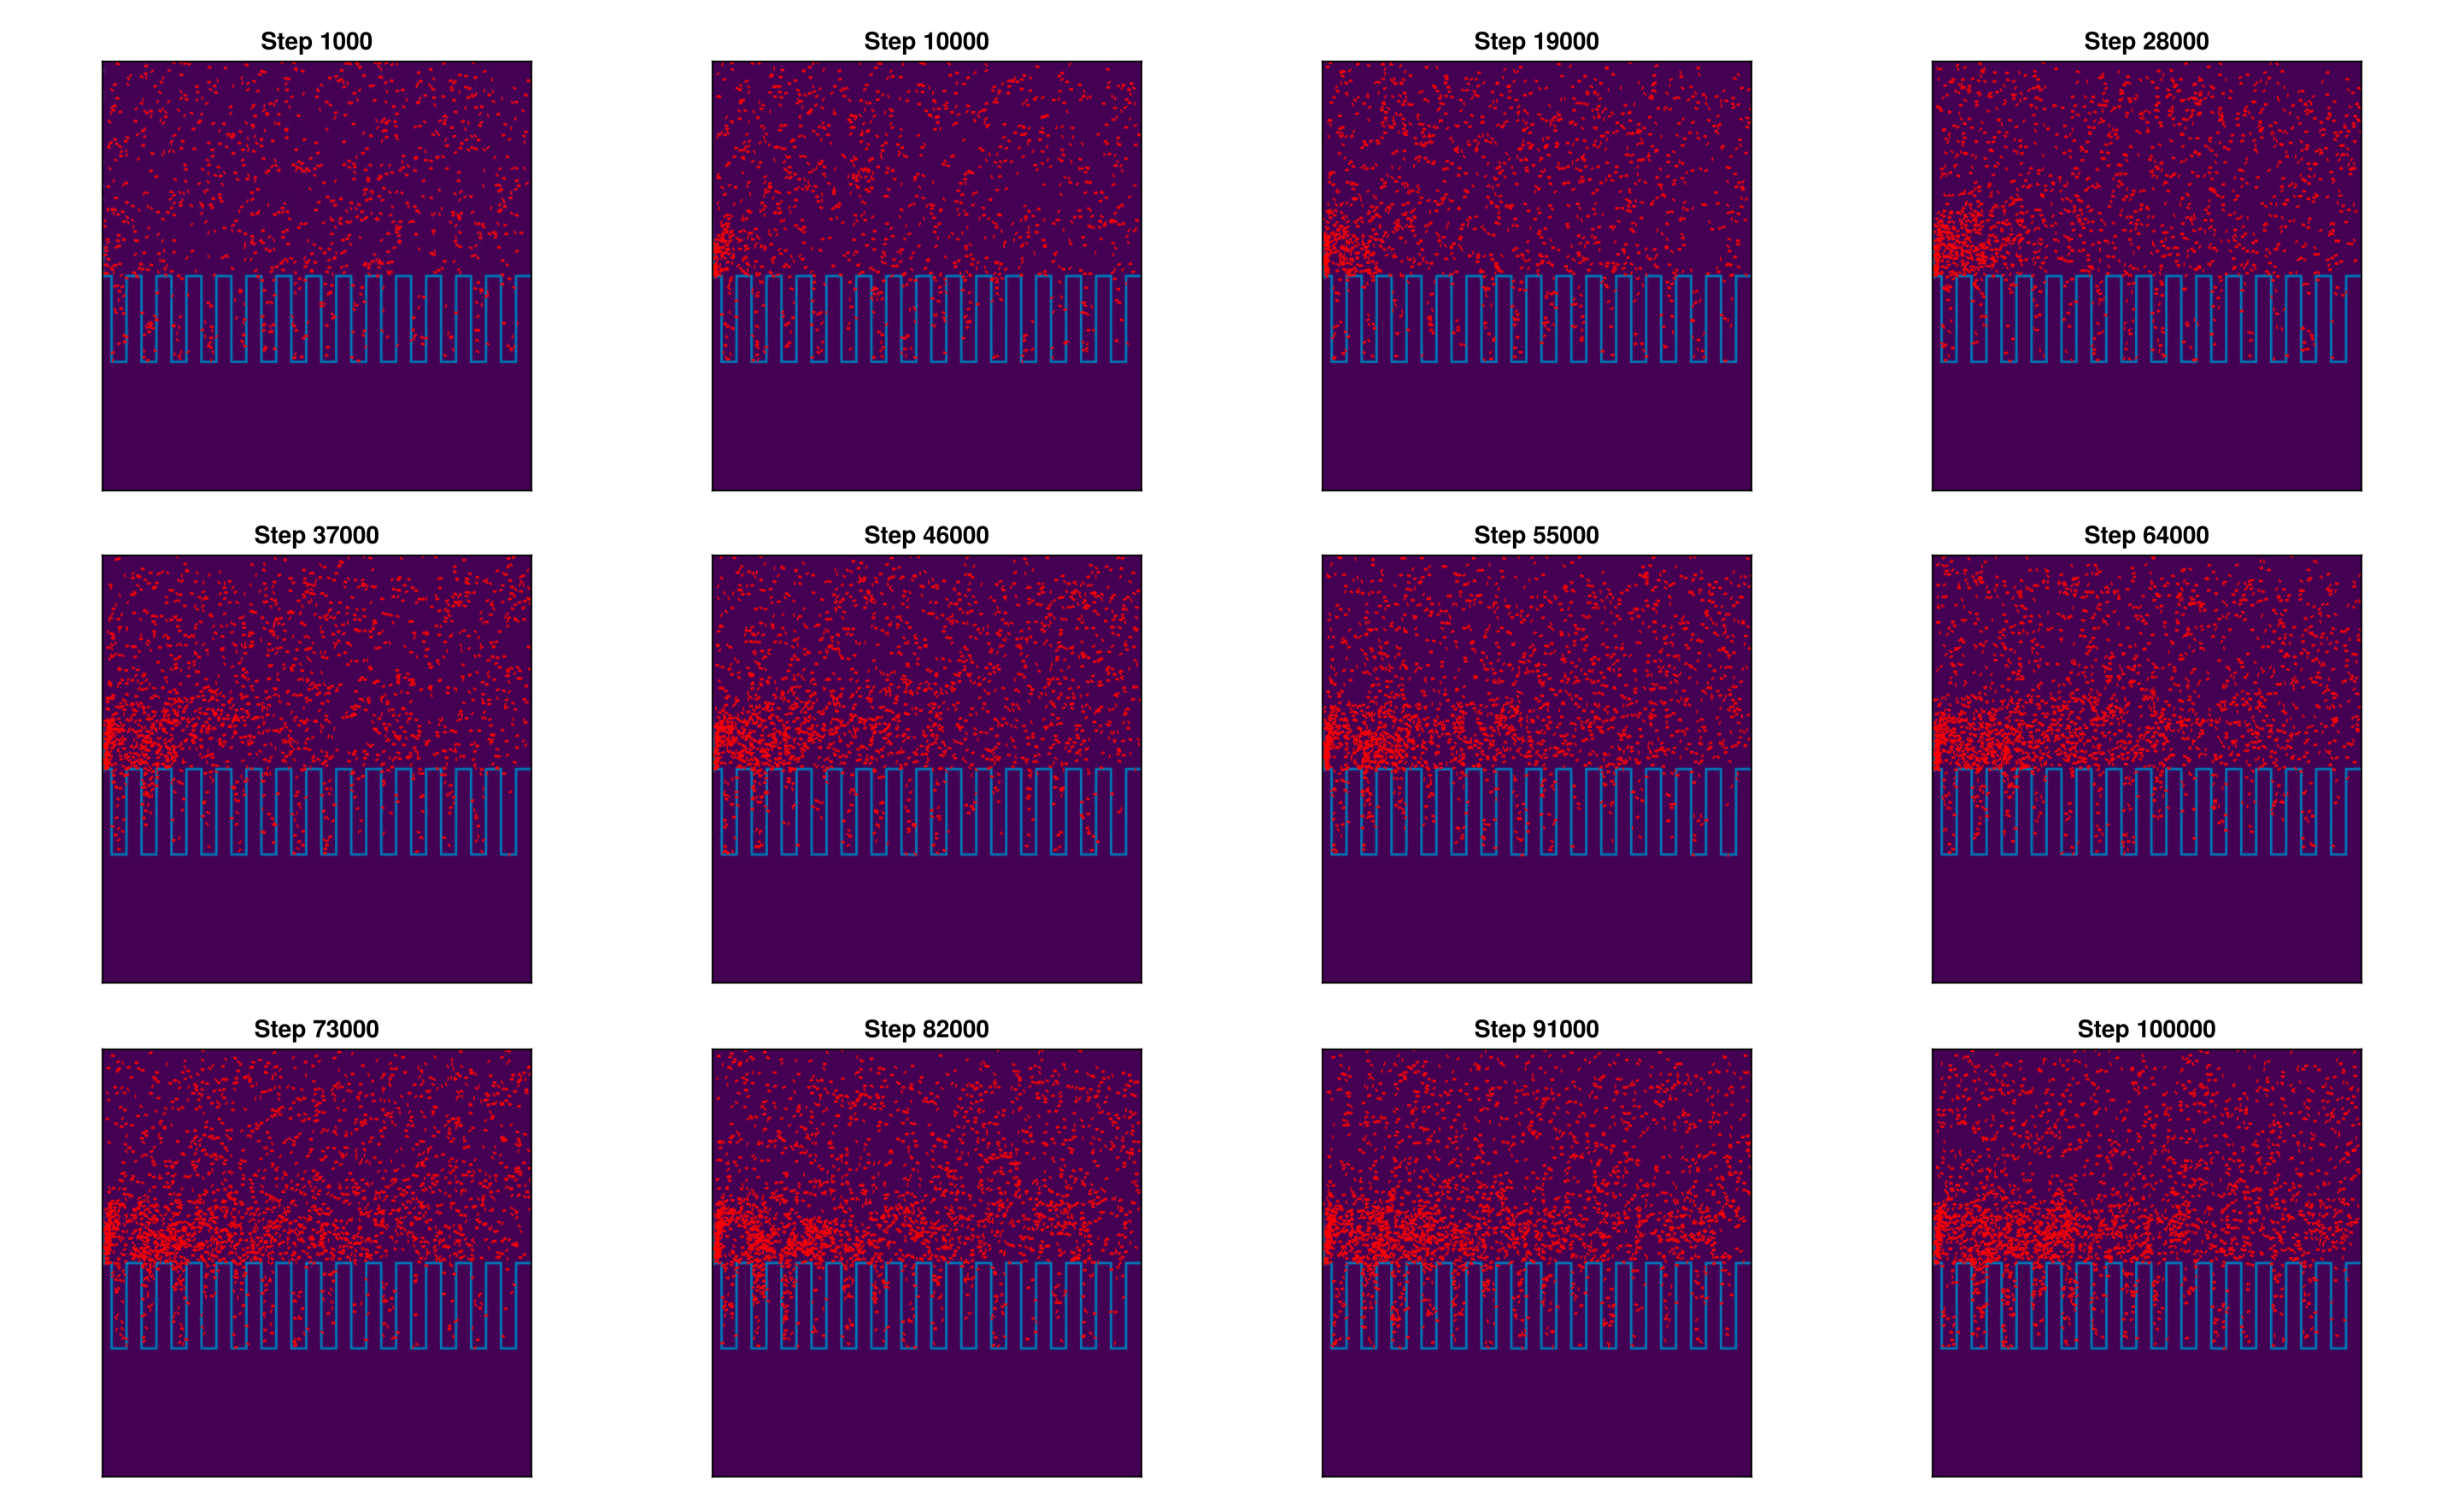

GLMakie.Screen(...)

In [15]:
fig4 = Figure(size=(900*4,600*4))
# steps = 5000
model_steps = 1000:1000:100000
# model_steps = 500:500:20000
steps_to_plot = unique(model_steps)[1:round(Int, length(unique(model_steps))/11):end]

jldopen("c_all_n0.5_lc_100_ve_5.jld2", "r") do file 
    for (j, step) in enumerate(steps_to_plot)

        row = ceil(Int, j / 4)
        col = (j - 1) % 4 + 1
        # col1 = columns[j]
        ax = Axis(fig4[row, col], aspect = 1, title="Step $step")

        g = file[@sprintf("step_%06d", step)]
    
        mm_grid = g["mm_grid_s"]
        mm = reshape(mm_grid, (com.NMedium[1], com.NMedium[2]))

        hm = heatmap!(ax, 
                    range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm_s)[1]),
                    range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm_s)[1]),
                    mm_grid, 
                    colormap=:viridis
                    )

        xs = 0:0.1:1000
        ys = [wall_y(x, 70, 100, 500, 20, 1000) for x in xs]

        lines!(ax, xs, ys)


        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = 3
            
        # Compute rod endpoints
        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        for i in 1:length(x)
            if x[i] != 0
                linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
                linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
            end
        end
        hidedecorations!(ax)
        ylims!(ax, 250, 750)

        # Colorbar(fig4[1, j*2], hm, label="Chemoattractant")

    end
end
Makie.inline!(true)
display(fig4)

In [46]:
save("Plots/Cripts/Test_sims/all_n05_lc100_ve5.png", fig4)

In [14]:
Dc = 10
delta = 0.0025
depths = [100, 150, 200]
ves = [5, 15]
ns = [0.5, 7.0]

for (idx, n) in enumerate(ns)

    for (d_idx, d) in enumerate(depths)
        depth = depths[d_idx]

        for (v_idx, ve) in enumerate(ves)

            println("Running simulation with parameters: ", depths[d_idx], " and ", n, " and ", ve)

            x1, x2, y1, y2 = 0, 1000, 0, 1000
            med1, med2 = 500, 500

            width = 70
            
            y_start = y2/2
            x_start = 20
            x_end = x2
            dx = (x2 - x1) / med1
            dy = (y2 -y1) / med2

            xcoord(i1_) = x1 + (i1_ - 1) * dx
            ycoord(i2_) = y1 + (i2_ - 1) * dy
            Nx = med1
            Ny = med2

            mask_raw = zeros(Bool, med1, med2)
            M0 = zeros(Bool, med1, med2)
            MXL = zeros(Bool, med1, med2)
            MXR = zeros(Bool, med1, med2)
            MYT = zeros(Bool, med1, med2)

            for i in 1:Nx, j in 1:Ny
                x = xcoord(i)
                y = ycoord(j)
                mask_raw[i,j] = y < wall_y(x, width, depth, y_start, x_start, x_end)
            end

            for i in 2:Nx-1, j in 2:Ny-1
                if mask_raw[i,j] &&
                mask_raw[i+1,j] &&
                mask_raw[i-1,j] &&
                mask_raw[i,j+1] &&
                mask_raw[i,j-1] &&
                mask_raw[i+1,j+1] &&
                mask_raw[i+1,j-1] &&
                mask_raw[i-1,j+1] &&
                mask_raw[i-1,j-1]

                    M0[i,j] = true
                end
            end

            M0[1,   :] .= true
            M0[500, :] .= true
            M0[1,   250:end] .= false
            M0[500, 250:end] .= false
            M0[:, 1] .= true

            for i in 2:Nx-1, j in 2:Ny-1

                if M0[i,j] == 1

                            # --- HORIZONTAL LINES ---
                            # bottom edge (neighbor below is outside)
                    if M0[i, j-1] == 0
                        MYT[i,j] = true
                    end

                            # top edge (neighbor above is outside)
                    if M0[i, j+1] == 0
                        MYT[i,j] = true
                    end


                            # --- LEFT WALL ---
                    if M0[i-1, j] == 0
                        MXL[i,j] = true
                    end


                            # --- RIGHT WALL ---
                    if M0[i+1, j] == 0
                        MXR[i,j] = true
                    end

                end
            end

            MYT[1,   248:249] .= true
            MYT[500,   248:249] .= true

            MB = zeros(Bool, 500, 500)
            MB[:, 375:500] .= true

            com = Community(
                crypts_all,
                N=1000,
                dt=0.01,
                simBox = [0.0 1000.0; 0.0 1000.0],
                NMedium = [500,500]
            )

            m = 1/100
            g = 1/10000
            d = 1

            com.Dr_run = 0.062

            com.v = 20.0    #Velocitat bacteries biològica


            com.ωFrec = 1.3
            com.Ki = 0.0182
            com.Ka = 3.0
            com.Nrec = 6.0
            com.ε0   = 6.0
            com.ε1   = -1.0
            com.ε2   = 80
            com.ε3   = 80

            com.τm = 1

            com.α   = 6.0

            com.K = 2.0 

            com.Ky = 100.0
            com.Kz = 10.0
            com.Z = 5.0
            com.Yy = 0.1

            com.m = 1.        
            com.d = 1.        
            com.l = 3;

            com.DMedium_o = 20
            com.DMedium_r = 5
            com.DMedium_s = Dc / n

            com.delta_o = 0.00125
            com.delta_r = 0.005
            com.delta_s = Dc * n

            com.x = zeros(com.N)
            com.y = zeros(com.N)

            count = 0

            while count < com.N
                x_try = rand(Uniform(1, 1000))   ## Limit 750 remember
                y_try = rand(Uniform(1, 750))

                # map to mask indices
                i = Int(floor(x_try / 2)) + 1
                j = Int(floor(y_try / 2)) + 1

                # bounds safety
                if i < 1 || i > y_start || j < 1 || j > y_start
                    continue
                end

                if M0[i, j] == 0
                    count += 1
                    com.x[count] = x_try
                    com.y[count] = y_try
                end
            end

            com.theta = rand(Uniform(0, 2*pi),com.N)

            com.methyl .= 0.0
            com.Yp .= com.K

            com.active .= true 

            com.S_o = 0.005
            com.S_r = 0.0025
            com.S_s = 0.0025

            com.ve = zeros(com.NMedium[1], com.NMedium[2])

            L = 100.0   # thickness of transition layer (tune this)

            for i1 in 1:com.NMedium[1], i2 in 1:com.NMedium[2]
                y = ycoord(i2)

                if y <= y_start
                    # Inside crypt → no flow
                    com.ve[i1, i2] = 0.0

                elseif y < y_start + L
                    # Transition region → smooth increase
                    f = (y - y_start) / L
                    com.ve[i1, i2] = ve * f^2

                else
                    # Bulk lumen → full flow
                    com.ve[i1, i2] = ve
                end
            end
            com.mm_o = o2grid  # Inicialitzar amb gradient ja estable
            com.mm_r = repgrid  # Inicialitzar amb gradient ja estable

            outfile = "c_all_n$(n)_lc_$(depths[d_idx])_ve_$(ve).jld2"
            steps = 100000
            println(outfile)

            loadToPlatform!(com, preallocateAgents=100000)

            jldopen(outfile, "w") do file
                
                for step in 1:steps
                    CellBasedModels.step!(com)
                    if step % 1000 == 0
                        stepname = @sprintf("step_%06d", step)
                        g = JLD2.Group(file, stepname)

                        # Agent-level arrays (length = N)
                        g["x"] = copy(com.x)
                        g["y"] = copy(com.y)
                        g["theta"] = copy(com.theta)

                        # Medium grid (saved once per step)
                        g["mm_grid_o"] = copy(com.mm_o)
                        g["mm_grid_r"] = copy(com.mm_r)
                        g["mm_grid_s"] = copy(com.mm_s)
                    end
                end
            end
        end
    end
end


Running simulation with parameters: 100 and 0.5 and 5
c_all_n0.5_lc_100_ve_5.jld2
Running simulation with parameters: 100 and 0.5 and 15
c_all_n0.5_lc_100_ve_15.jld2
Running simulation with parameters: 150 and 0.5 and 5
c_all_n0.5_lc_150_ve_5.jld2
Running simulation with parameters: 150 and 0.5 and 15
c_all_n0.5_lc_150_ve_15.jld2


CompositeException: TaskFailedException

    nested task error: BoundsError: attempt to access 101000-element Vector{Float64} at index [-1]
    Stacktrace:
     [1] getindex
       @ .\essentials.jl:13 [inlined]
     [2] macro expansion
       @ c:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl\examples\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W1sZmlsZQ==.jl:236 [inlined]
     [3] macro expansion
       @ C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl\src\AgentStructure\auxiliar.jl:166 [inlined]
     [4] (::var"#162#threadsfor_fun#37"{var"#162#threadsfor_fun#34#38"{Float64, Float64, Int64, Vector{Int64}, Int64, Vector{Float64}, Base.Threads.Atomic{Int64}, Matrix{Float64}, Float64, Float64, Base.Threads.Atomic{Int64}, Base.Threads.Atomic{Int64}, Vector{Int64}, Vector{Int64}, Vector{Float64}, Vector{Float64}, Vector{Float64}, Vector{Float64}, Vector{Float64}, Vector{Bool}, Vector{Float64

In [3]:
dfs_chemo = Dict{Tuple{Float64, Float64, Float64}, DataFrame}()

depths = [100, 150, 200]
ves = [5, 15]
ns = [0.5, 7.0]

for (idx, n) in enumerate(ns)

    for (d_idx, d) in enumerate(depths)
        depth = depths[d_idx]

        for (v_idx, ve) in enumerate(ves)

            data = Dict{Int, Any}()
            steps = 100000
            jldopen("c_all_n$(n)_lc_$(depths[d_idx])_ve_$(ve).jld2", "r") do file
                for step in 1000:1000:steps
                    key = file[@sprintf("step_%06d", step)]
                    data[step] = Dict(
                        "x" => copy(key["x"]),
                        "y" => copy(key["y"])
                    )
                end
            end

            x1, x2, y1, y2 = 0, 1000, 0, 1000
            med1, med2 = 500, 500

            width = 70
            y_start = y2/2
            x_start = 20
            x_end = x2
            dx = (x2 - x1) / med1
            dy = (y2 -y1) / med2

            xcoord(i1_) = x1 + (i1_ - 1) * dx
            ycoord(i2_) = y1 + (i2_ - 1) * dy
            Nx = med1
            Ny = med2

            mask_raw = zeros(Bool, med1, med2)
            M0 = zeros(Bool, med1, med2)
            MXL = zeros(Bool, med1, med2)
            MXR = zeros(Bool, med1, med2)
            MYT = zeros(Bool, med1, med2)

            for i in 1:Nx, j in 1:Ny
                x = xcoord(i)
                y = ycoord(j)
                mask_raw[i,j] = y < wall_y(x, width, depth, y_start, x_start, x_end)
            end

            for i in 2:Nx-1, j in 2:Ny-1
                if mask_raw[i,j] &&
                mask_raw[i+1,j] &&
                mask_raw[i-1,j] &&
                mask_raw[i,j+1] &&
                mask_raw[i,j-1] &&
                mask_raw[i+1,j+1] &&
                mask_raw[i+1,j-1] &&
                mask_raw[i-1,j+1] &&
                mask_raw[i-1,j-1]

                    M0[i,j] = true
                end
            end

            for i in 2:Nx-1, j in 2:Ny-1

                if M0[i,j] == 1

                    # --- HORIZONTAL LINES ---
                    # bottom edge (neighbor below is outside)
                    if M0[i, j-1] == 0
                        MYT[i,j] = true
                    end

                    # top edge (neighbor above is outside)
                    if M0[i, j+1] == 0
                        MYT[i,j] = true
                    end


                    # --- LEFT WALL ---
                    if M0[i-1, j] == 0
                        MXL[i,j] = true
                    end


                    # --- RIGHT WALL ---
                    if M0[i+1, j] == 0
                        MXR[i,j] = true
                    end

                end
            end


            ncripts = 14
            steps = 1000:1000:100000
            sizes = length(steps)
            counts = zeros(ncripts, sizes)
            agents = Float64[]
            counts_in = Float64[]
            counts_out = Float64[]

            density_lumen = Float64[]
            density_crypt = Float64[]

            residence_time = Float64[]

            occupancy = Float64[]

            for i in 1:sizes
                count_in = 0
                count_out = 0
                agent = 0
                step = steps[i]
                g = data[step]
                x = g["x"]
                y = g["y"]
                
                for j in 1:length(x)

                    if y[j] < 500 && y[j] != 0
                        count_in += 1
                        agent += 1

                    elseif y[j] > 500 && y[j] != 0
                        count_out += 1
                        agent += 1

                    end          

                end

                area_lumen = 250 * 1000
                area_crypt = ncripts * (70/2) * 200 ## ncripts * width/2 * depth
                d_l = count_out / area_lumen
                d_c = count_in / area_crypt
                percentatge_in = (count_in / agent) * 100

                push!(counts_in, count_in)
                push!(counts_out, count_out)
                push!(agents, agent)
                push!(density_lumen, d_l)
                push!(density_crypt, d_c)
                push!(occupancy, percentatge_in)
            end
            
            right_wall = findall(MXR[:, 200] .== 1) .* 2
            left_wall  = findall(MXL[:, 200] .== 1) .* 2

            n_bins = 14
            y_top = y_start
            y_bottom = y_start - depth

            steps = 1000:1000:100000
            n_steps = length(steps)

            counts = zeros(n_bins, n_steps)

            # Precompute x-interval bounds for each bin
            x_left  = right_wall[1:n_bins]
            x_right = left_wall[2:n_bins+1]
            
            for (i, step) in enumerate(steps)
                g = data[step]
                x = g["x"]
                y = g["y"]

                local_counts = zeros(Int, n_bins)

                for j in eachindex(x)
                    if y[j] >= y_top
                        continue
                    end

                    xj = x[j]

                    # find bin (much cleaner than long elseif chain)
                    for b in 1:n_bins
                        if x_right[b] > xj > x_left[b]
                            local_counts[b] += 1
                            break
                        end
                    end
                end

                counts[:, i] .= local_counts
            end

            df = DataFrame(
                time_vec = sizes,
                num_agents = agents,
                occupancies = occupancy,
                d_lumen = density_lumen,
                d_crypt = density_crypt,
                num_inside = counts_in,
                num_outside = counts_out, 
                crypt_1 = counts[1, :],
                crypt_2 = counts[2, :],
                crypt_3 = counts[3, :],
                crypt_4 = counts[4, :],
                crypt_5 = counts[5, :],
                crypt_6 = counts[6, :],
                crypt_7 = counts[7, :],
                crypt_8 = counts[8, :],
                crypt_9 = counts[9, :],
                crypt_10 = counts[10, :],
                crypt_11 = counts[11, :],
                crypt_12 = counts[12, :],
                crypt_13 = counts[13, :],
                crypt_14 = counts[14, :]
            )

            dfs_chemo[(n, depth, ve)] = df
        end
    end
end

KeyError: KeyError: key "step_001000" not found

In [4]:
dfs_chemo

Dict{Tuple{Float64, Float64, Float64}, DataFrame} with 3 entries:
  (0.5, 150.0, 5.0)  => 100×21 DataFrame…
  (0.5, 100.0, 5.0)  => 100×21 DataFrame…
  (0.5, 100.0, 15.0) => 100×21 DataFrame…

In [7]:
steps = 1000:1000:100000
sizes = length(steps)
ve = [5.0, 15.0]
lc = [100.0, 150.0]

for (v_idx, v) in enumerate(ve)
        
    for (l_idx, l) in enumerate(lc)

        df = dfs_chemo[(0.5, l, v)]

        fig = Figure(size=(1800, 1200))
        ax1 = Axis(fig[1,1], title = "Proportion", xlabel = "Time (s)", ylabel = "nº agents in / nº agents out")
        ax2 = Axis(fig[1,2], title = "Biomass", xlabel = "Time (s)", ylabel = "nº agents")
        ax3 = Axis(fig[2,1], title = "Enrichment", xlabel = "Time (s)", ylabel = "p crypt / p lumen")
        ax4 = Axis(fig[2,2], title = "Residence time", xlabel = "Time (s)", ylabel = "Distribution")
        ax5 = Axis(fig[3,1], title = "Occupancy", xlabel = "Time (s)", ylabel = "% bacteria inside")
        ax6 = Axis(fig[3,2], title = "Cript colonization over time", xlabel = "Time (s)", ylabel = "nº agents in")

        lines!(ax2, (1:sizes)*10, df.num_agents, label = "Total")
        lines!(ax2, (1:sizes)*10, df.num_inside, label = "In crypt")
        lines!(ax2, (1:sizes)*10, df.num_outside, label = "In lumen")

        lines!(ax3, (1:sizes)*10, df.d_crypt ./ df.d_lumen)

        proportion = df.num_inside ./ df.num_outside
        lines!(ax1, (1:sizes)*10, proportion)

        # hist!(ax4, residence_time, bins = 50)

        lines!(ax5, (1:sizes)*10, df.occupancies)

        lines!(ax6, (1:sizes), df.crypt_1, label = "Cript 1", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_2, label = "Cript 2", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_3, label = "Cript 3", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_4, label = "Cript 4", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_5, label = "Cript 5", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_6, label = "Cript 6", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_7, label = "Cript 7", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_8, label = "Cript 8", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_9, label = "Cript 9", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_10, label = "Cript 10", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_11, label = "Cript 11", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_12, label = "Cript 12", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_13, label = "Cript 13", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_14, label = "Cript 14", linewidth         = 1)

        fig[1, 3] = Legend(fig, ax2)
        fig[3, 3] = Legend(fig, ax6)
        fig
        save("Plots/Cripts/Test_sims/analysis_chemo_ve$(v)_l$(l)_lambda_05.png", fig)
    end
end


KeyError: KeyError: key (0.5, 150.0, 15.0) not found

In [34]:
steps = 100000
steps_1 = 100:100:steps
sizes = length(steps_1)

1000

In [14]:
Dc = 10
delta = 0.0025
depths = [100, 150, 200]
ve = 10
ns = [0.5, 1.0, 4.0, 6.0]
steps = 100000

for (idx, n) in enumerate(ns)

    for i in 1:length(depths)

        println("Running simulation with parameters: ", depths[i], " and ", n)

        x1, x2, y1, y2 = 0, 500, 0, 500
        med1, med2 = 250, 250

        width = 62
        depth = depths[i]
        y_start = y2/2
        x_start = 20
        x_end = x2
        dx = (x2 - x1) / med1
        dy = (y2 -y1) / med2

        xcoord(i1_) = x1 + (i1_ - 1) * dx
        ycoord(i2_) = y1 + (i2_ - 1) * dy
        Nx = med1
        Ny = med2

        mask_raw = zeros(Bool, med1, med2)
        M0 = zeros(Bool, med1, med2)
        MXL = zeros(Bool, med1, med2)
        MXR = zeros(Bool, med1, med2)
        MYT = zeros(Bool, med1, med2)

        for i in 1:Nx, j in 1:Ny
            x = xcoord(i)
            y = ycoord(j)
            mask_raw[i,j] = y < wall_y(x, width, depth, y_start, x_start, x_end)
        end

        for i in 2:Nx-1, j in 2:Ny-1
            if mask_raw[i,j] &&
            mask_raw[i+1,j] &&
            mask_raw[i-1,j] &&
            mask_raw[i,j+1] &&
            mask_raw[i,j-1] &&
            mask_raw[i+1,j+1] &&
            mask_raw[i+1,j-1] &&
            mask_raw[i-1,j+1] &&
            mask_raw[i-1,j-1]

                M0[i,j] = true
            end
        end

        for i in 2:Nx-1, j in 2:Ny-1

            if M0[i,j] == 1

                # --- HORIZONTAL LINES ---
                # bottom edge (neighbor below is outside)
                if M0[i, j-1] == 0
                    MYT[i,j] = true
                end

                # top edge (neighbor above is outside)
                if M0[i, j+1] == 0
                    MYT[i,j] = true
                end


                # --- LEFT WALL ---
                if M0[i-1, j] == 0
                    MXL[i,j] = true
                end


                # --- RIGHT WALL ---
                if M0[i+1, j] == 0
                    MXR[i,j] = true
                end

            end
        end

        data = Dict{Int, Any}()
        jldopen("c_n$(n)_lc_$(depths[i]).jld2", "r") do file
            for step in 100:100:steps
                key = file[@sprintf("step_%06d", step)]
                data[step] = Dict(
                    "x" => copy(key["x"]),
                    "y" => copy(key["y"]),
                    "mm_grid" => copy(key["mm_grid"])
                )
            end
        end

        # Fer matrius per cada set
        ncripts = 8
        right_wall = findall(MXR[:, 100] .== 1) .* 2
        left_wall = findall(MXL[:, 100] .== 1) .* 2
        x1_1, x1_2, x1_3, x1_4, x1_5, x1_6, x1_7, x1_8 = right_wall[1:8]
        x2_1, x2_2, x2_3, x2_4, x2_5, x2_6, x2_7, x2_8 = left_wall[2:9]

        y_bottom = y_start - depth
        y_top = y_start

        steps_1 = 100:100:steps
        sizes = length(steps_1)
        counts = zeros(ncripts, sizes)

        for i in 1:sizes
            step = steps_1[i]
            g = data[step]
            x = g["x"]
            y = g["y"]

            count1 = 0
            count2 = 0
            count3 = 0
            count4 = 0
            count5 = 0
            count6 = 0
            count7 = 0
            count8 = 0

            for j in 1:length(x)
            
                if x2_1 > x[j] > x1_1 && y[j] < y_top
                    count1 += 1
                elseif x2_2 > x[j] > x1_2 && y[j] < y_top
                    count2 += 1
                elseif x2_3 > x[j] > x1_3 && y[j] < y_top
                    count3 += 1
                elseif x2_4 > x[j] > x1_4 && y[j] < y_top
                    count4 += 1
                elseif x2_5 > x[j] > x1_5 && y[j] < y_top
                    count5 += 1
                elseif x2_6 > x[j] > x1_6 && y[j] < y_top
                    count6 += 1
                elseif x2_7 > x[j] > x1_7 && y[j] < y_top
                    count7 += 1
                elseif x2_8 > x[j] > x1_8 && y[j] < y_top
                    count8 += 1
                end
            end

            counts[1, i] = count1
            counts[2, i] = count2
            counts[3, i] = count3
            counts[4, i] = count4
            counts[5, i] = count5
            counts[6, i] = count6
            counts[7, i] = count7
            counts[8, i] = count8
        end

        fig = Figure(size=(900, 600))
        ax = Axis(fig[1, 1], xlabel = "Time", ylabel = "Nº cells", title = "Cript colonization over time")
        lines!(ax, (1:sizes), counts[1, :], label = "Cript 1", linewidth = 1)
        lines!(ax, (1:sizes), counts[2, :], label = "Cript 2", linewidth = 1)
        lines!(ax, (1:sizes), counts[3, :], label = "Cript 3", linewidth = 1)
        lines!(ax, (1:sizes), counts[4, :], label = "Cript 4", linewidth = 1)
        lines!(ax, (1:sizes), counts[5, :], label = "Cript 5", linewidth = 1)
        lines!(ax, (1:sizes), counts[6, :], label = "Cript 6", linewidth = 1)
        lines!(ax, (1:sizes), counts[7, :], label = "Cript 7", linewidth = 1)
        lines!(ax, (1:sizes), counts[8, :], label = "Cript 8", linewidth = 1)

        fig[1,2] = Legend(fig, ax, "Cripts")

        save("Plots/Cripts/Test_sims/colonization_time_n$(n)_lc$(depths[i]).png", fig)


        grid_values = zeros(ncripts, sizes)

        x2 = Int.(left_wall[2:9] ./ 2)
        x1 = Int.(right_wall[1:8] ./2)
        y1 = Int(y_bottom / 2)
        y2 = Int(y_start / 2)

        for i in 1:sizes
            step = steps_1[i]
            g = data[step]
            grid = g["mm_grid"]
            for j in 1:ncripts
            
                cript = grid[x1[j]:x2[j], y1:y2]
                mm_mean = mean(cript)

                grid_values[j, i] = mm_mean

            end
        end

        fig2 = Figure(size=(900, 600))
        ax2 = Axis(fig2[1, 1], xlabel = "Time", ylabel = "Nº cells", title = "Cript mm concentration over time")
        lines!(ax2, (1:sizes), grid_values[1, :], label = "Cript 1")
        lines!(ax2, (1:sizes), grid_values[2, :], label = "Cript 2")
        lines!(ax2, (1:sizes), grid_values[3, :], label = "Cript 3")
        lines!(ax2, (1:sizes), grid_values[4, :], label = "Cript 4")
        lines!(ax2, (1:sizes), grid_values[5, :], label = "Cript 5")
        lines!(ax2, (1:sizes), grid_values[6, :], label = "Cript 6")
        lines!(ax2, (1:sizes), grid_values[7, :], label = "Cript 7")
        lines!(ax2, (1:sizes), grid_values[8, :], label = "Cript 8")
        fig2[1,2] = Legend(fig2, ax2, "Cripts")

        save("Plots/Cripts/Test_sims/concentration_time_n$(n)_lc$(depths[i]).png", fig2)
    end
end

Running simulation with parameters: 100 and 0.5
Running simulation with parameters: 150 and 0.5
Running simulation with parameters: 200 and 0.5
Running simulation with parameters: 100 and 1.0
Running simulation with parameters: 150 and 1.0
Running simulation with parameters: 200 and 1.0
Running simulation with parameters: 100 and 4.0
Running simulation with parameters: 150 and 4.0
Running simulation with parameters: 200 and 4.0
Running simulation with parameters: 100 and 6.0
Running simulation with parameters: 150 and 6.0
Running simulation with parameters: 200 and 6.0


In [2]:
@load "metrics_redo.jld2" metrics_redo

1-element Vector{Symbol}:
 :metrics_redo

In [10]:
metrics_redo

Row,v,lambda,mu_x,mu_y,sigma_x,sigma_y,sigma,k_x,k_y,k,D
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,20.0,4.0,0.532502,0.478501,15.1084,15.3948,15.2516,0.0144832,0.0153553,0.0149193,3.4704
2,10.0,5.0,0.261798,0.336729,7.47614,7.65055,7.56335,0.0141562,0.0152452,0.0147007,0.840942
3,100.0,5.0,2.30087,2.16082,72.8249,73.5305,73.1777,0.0150301,0.0161163,0.0155732,83.3941
4,5.0,5.0,0.154884,0.189023,3.65981,3.6977,3.67875,0.0184778,0.0185276,0.0185027,0.250401
5,10.0,0.75,2.59234,2.48379,18.8565,18.8022,18.8293,0.0103092,0.0105144,0.0104118,3.69143
6,20.0,5.0,0.532151,0.656293,14.8697,14.898,14.8839,0.0146034,0.0127954,0.0136994,3.03483
7,10.0,0.5,4.44479,4.47306,25.7354,26.0306,25.883,0.00683783,0.00711385,0.00697584,4.67333
8,100.0,0.75,25.1991,25.2565,186.81,188.39,187.6,0.0101498,0.0101605,0.0101552,357.398
9,10.0,1.0,1.56504,1.57395,14.8719,14.9968,14.9343,0.0123888,0.0124633,0.0124261,2.77143


In [16]:
using GLM

0.16940178235570508 5.396623423990648
0.04732630024969282 0.8085060622308807
0.03572959544824939 0.10443168917457164
0.026288097832517236 -0.0806069174733933
0.015400241442088 -0.36743618136311135
0.012459931515535842 -0.30725155122842723
0.009660830215035561 -0.12500243008394785
0.008346919686633841 -0.0827727420298858
0.00812213737882683 -0.05239109818665107
0.006970823309409327 0.06260983972158701
0.007106240411673685 0.08855655201483315
0.008015456676838584 -0.09044381105435796
0.007748876756900434 -0.10337830313787685


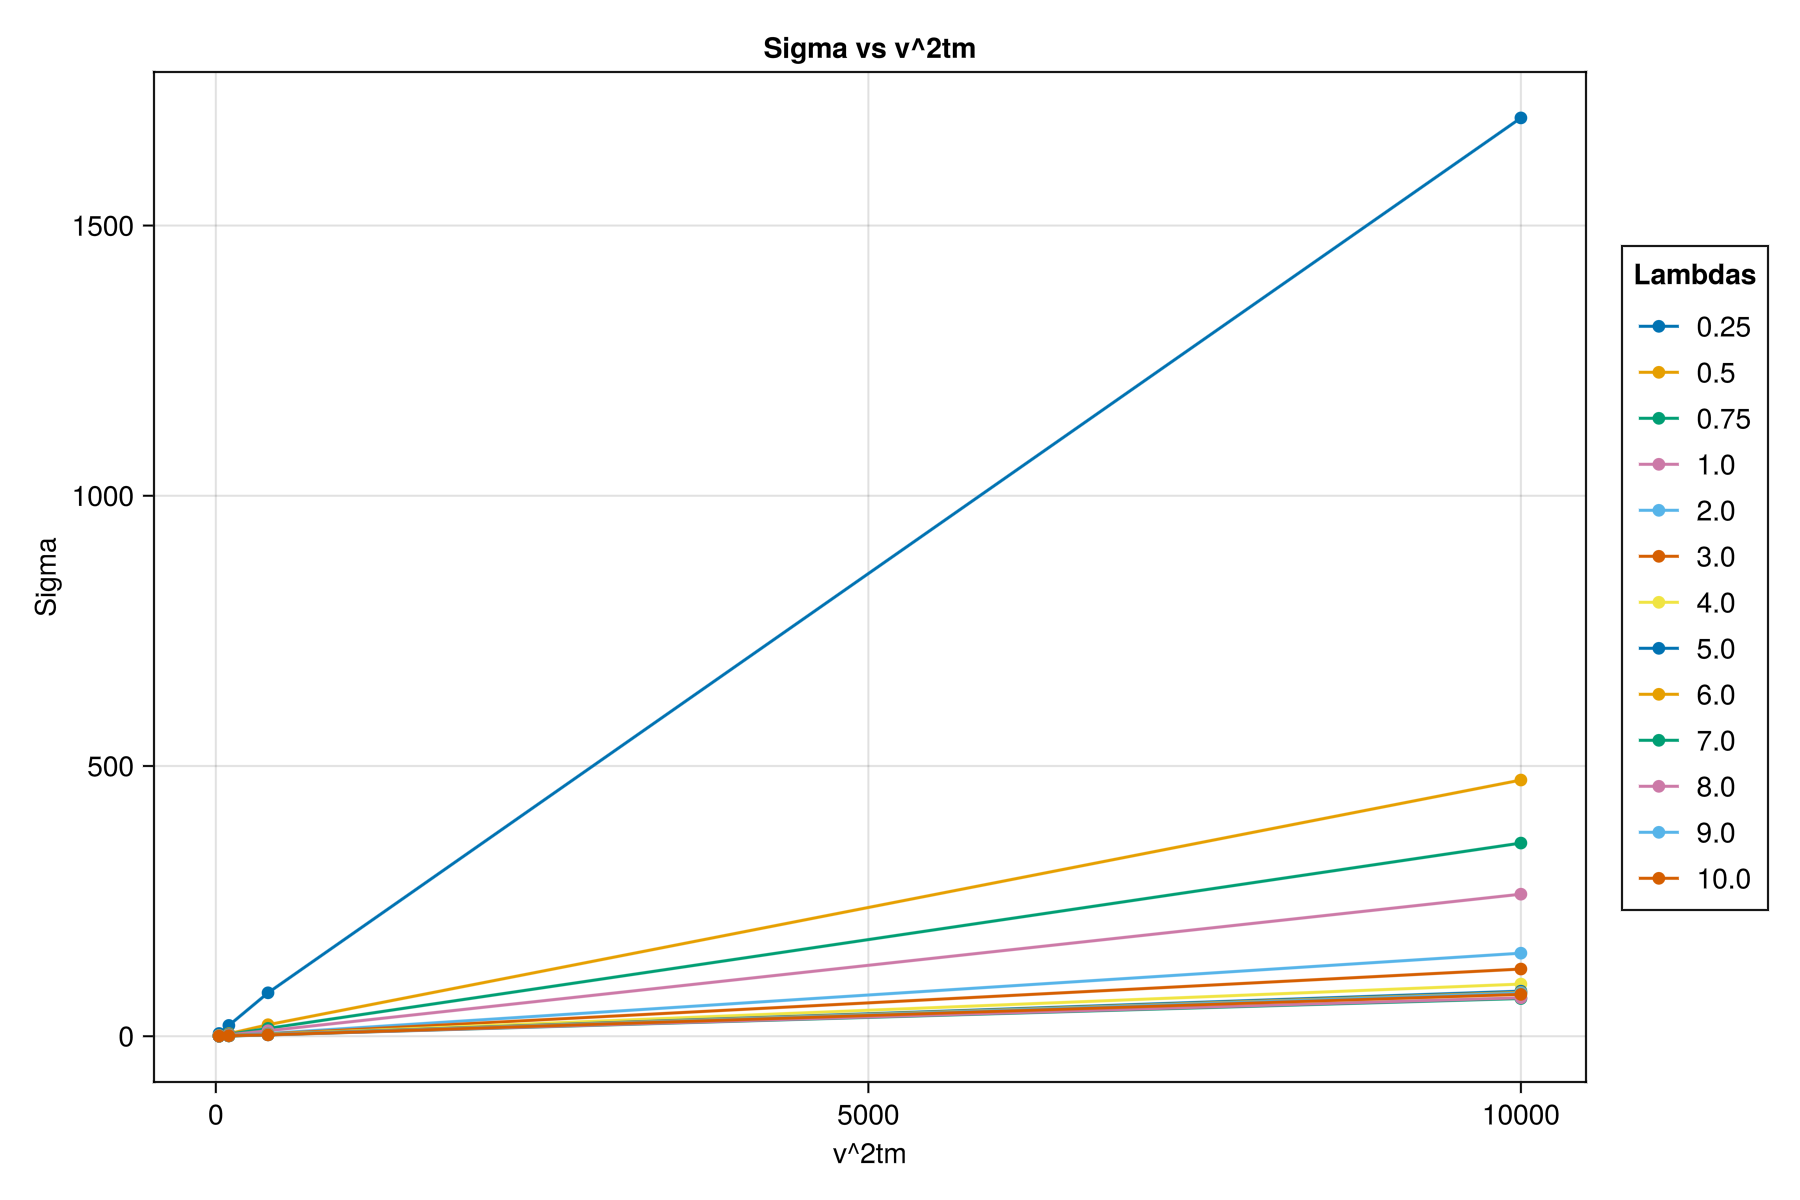

In [ ]:
velocities = [5, 10, 20, 100]
lambda_n = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
diff = Float64[]
vtm = Float64[]

fig = Figure(size=(900, 600))
ax = Axis(fig[1,1], title = "Sigma vs v^2tm", xlabel = "v^2tm", ylabel = "Sigma")
for (idx, l) in enumerate(lambda_n)
    diff = Float64[]
    vtm = Float64[]
    for (idx, v) in enumerate(velocities)
        mask = (metrics_redo.lambda .== l) .& (metrics_redo.v .== v)
        row = metrics_redo.D[mask]
        D = row[1]
        valor = v^2
        push!(diff, D)
        push!(vtm, valor)

    end
    scatterlines!(ax, vtm, diff, label = " $(l)")
    df = DataFrame(x = vtm, y = diff)
    model = lm(@formula(y ~ x), df)

    a = coef(model)[2]   # slope
    b = coef(model)[1]
    println(a, " ", b)
end
fig[1,2] = Legend(fig, ax, "Lambdas")
fig



In [ ]:
using Statistics

slopes = Float64[]

for (idx, l) in enumerate(lambda_n)
    diff = Float64[]
    vtm = Float64[]
    
    for v in velocities
        mask = (metrics_redo.lambda .== l) .& (metrics_redo.v .== v)
        D = metrics_redo.D[mask][1]
        
        push!(diff, D)
        push!(vtm, v^2)
    end
    
    # linear fit slope (since model is D = a x)
    a = sum(vtm .* diff) / sum(vtm .* vtm)
    push!(slopes, a)
    
    scatterlines!(ax, vtm, diff, label="λ = $l")
end

In [22]:
lambdas = [0.079, 0.158, 0.237, 0.316, 0.548, 0.822, 1.095, 1.369, 1.643, 1.917, 2.191, 2.465, 2.739]

13-element Vector{Float64}:
 0.079
 0.158
 0.237
 0.316
 0.548
 0.822
 1.095
 1.369
 1.643
 1.917
 2.191
 2.465
 2.739

In [23]:
lambda_in = 1 ./ lambdas

13-element Vector{Float64}:
 12.658227848101266
  6.329113924050633
  4.219409282700422
  3.1645569620253164
  1.824817518248175
  1.2165450121654502
  0.9132420091324202
  0.7304601899196493
  0.6086427267194157
  0.5216484089723527
  0.4564125969876769
  0.40567951318458423
  0.36509675063891933

In [21]:
slopes

13-element Vector{Float64}:
 0.16996880948104742
 0.047411250566264974
 0.0357405681613433
 0.026279628405413154
 0.015361634656826884
 0.012427648372881206
 0.00964769611932004
 0.008338222694777549
 0.00811663260825747
 0.006977401770540719
 0.007115545112627245
 0.008005953680213106
 0.007738014723839083

In [12]:
save("Plots/Fixed_source_model/sigma_vtm_all_scatter_sense100.png", fig)

In [43]:
dfs_PBC = Dict{Tuple{Float64, Float64}, DataFrame}()

depths = [100, 150, 200]
ns = ["05"]

for (idx, n) in enumerate(ns)

    for (d_idx, d) in enumerate(depths)
        depth = depths[d_idx]


            data = Dict{Int, Any}()
            steps = 25000
            jldopen("Crypts_sims_PBC/c_PBC_n_$(n)_lc_$(depths[d_idx]).jld2", "r") do file
                for step in 500:500:steps
                    key = file[@sprintf("step_%06d", step)]
                    data[step] = Dict(
                        "x" => copy(key["x"]),
                        "y" => copy(key["y"])
                    )
                end
            end

            x1, x2, y1, y2 = 0, 500, 0, 500
            med1, med2 = 250, 250

            width = 62
            y_start = y2/2
            x_start = 20
            x_end = x2
            dx = (x2 - x1) / med1
            dy = (y2 -y1) / med2

            xcoord(i1_) = x1 + (i1_ - 1) * dx
            ycoord(i2_) = y1 + (i2_ - 1) * dy
            Nx = med1
            Ny = med2

            mask_raw = zeros(Bool, med1, med2)
            M0 = zeros(Bool, med1, med2)
            MXL = zeros(Bool, med1, med2)
            MXR = zeros(Bool, med1, med2)
            MYT = zeros(Bool, med1, med2)

            for i in 1:Nx, j in 1:Ny
                x = xcoord(i)
                y = ycoord(j)
                mask_raw[i,j] = y < wall_y(x, width, depth, y_start, x_start, x_end)
            end

            for i in 2:Nx-1, j in 2:Ny-1
                if mask_raw[i,j] &&
                mask_raw[i+1,j] &&
                mask_raw[i-1,j] &&
                mask_raw[i,j+1] &&
                mask_raw[i,j-1] &&
                mask_raw[i+1,j+1] &&
                mask_raw[i+1,j-1] &&
                mask_raw[i-1,j+1] &&
                mask_raw[i-1,j-1]

                    M0[i,j] = true
                end
            end

            for i in 2:Nx-1, j in 2:Ny-1

                if M0[i,j] == 1

                    # --- HORIZONTAL LINES ---
                    # bottom edge (neighbor below is outside)
                    if M0[i, j-1] == 0
                        MYT[i,j] = true
                    end

                    # top edge (neighbor above is outside)
                    if M0[i, j+1] == 0
                        MYT[i,j] = true
                    end


                    # --- LEFT WALL ---
                    if M0[i-1, j] == 0
                        MXL[i,j] = true
                    end


                    # --- RIGHT WALL ---
                    if M0[i+1, j] == 0
                        MXR[i,j] = true
                    end

                end
            end


            ncripts = 8
            steps = 500:500:25000
            sizes = length(steps)
            counts = zeros(ncripts, sizes)
            agents = Float64[]
            counts_in = Float64[]
            counts_out = Float64[]

            density_lumen = Float64[]
            density_crypt = Float64[]

            residence_time = Float64[]

            occupancy = Float64[]

            for i in 1:sizes
                count_in = 0
                count_out = 0
                agent = 0
                step = steps[i]
                g = data[step]
                x = g["x"]
                y = g["y"]
                
                for j in 1:length(x)

                    if y[j] < 250 && y[j] != 0
                        count_in += 1
                        agent += 1

                    elseif y[j] > 250 && y[j] != 0
                        count_out += 1
                        agent += 1

                    end          

                end

                area_lumen = 250 * 500
                area_crypt = ncripts * (62/2) * depth ## ncripts * width/2 * depth
                d_l = count_out / area_lumen
                d_c = count_in / area_crypt
                percentatge_in = (count_in / agent) * 100

                push!(counts_in, count_in)
                push!(counts_out, count_out)
                push!(agents, agent)
                push!(density_lumen, d_l)
                push!(density_crypt, d_c)
                push!(occupancy, percentatge_in)
            end
            
            right_wall = findall(MXR[:, 100] .== 1) .* 2
            left_wall  = findall(MXL[:, 100] .== 1) .* 2

            n_bins = 8
            y_top = y_start
            y_bottom = y_start - depth

            steps = 500:500:25000
            n_steps = length(steps)

            counts = zeros(n_bins, n_steps)

            # Precompute x-interval bounds for each bin
            x_left  = right_wall[1:n_bins]
            x_right = left_wall[2:n_bins+1]
            
            for (i, step) in enumerate(steps)
                g = data[step]
                x = g["x"]
                y = g["y"]

                local_counts = zeros(Int, n_bins)

                for j in eachindex(x)
                    if y[j] >= y_top
                        continue
                    end

                    xj = x[j]

                    # find bin (much cleaner than long elseif chain)
                    for b in 1:n_bins
                        if x_right[b] > xj > x_left[b]
                            local_counts[b] += 1
                            break
                        end
                    end
                end

                counts[:, i] .= local_counts
            end

            df = DataFrame(
                time_vec = sizes,
                num_agents = agents,
                occupancies = occupancy,
                d_lumen = density_lumen,
                d_crypt = density_crypt,
                num_inside = counts_in,
                num_outside = counts_out, 
                crypt_1 = counts[1, :],
                crypt_2 = counts[2, :],
                crypt_3 = counts[3, :],
                crypt_4 = counts[4, :],
                crypt_5 = counts[5, :],
                crypt_6 = counts[6, :],
                crypt_7 = counts[7, :],
                crypt_8 = counts[8, :]

            )

            dfs_PBC[(0.5, depth)] = df

    end
end

In [37]:
dfs_PBC

Dict{Tuple{Float64, Float64}, DataFrame} with 6 entries:
  (3.0, 150.0) => 50×15 DataFrame…
  (7.0, 200.0) => 50×15 DataFrame…
  (3.0, 100.0) => 50×15 DataFrame…
  (7.0, 150.0) => 50×15 DataFrame…
  (7.0, 100.0) => 50×15 DataFrame…
  (3.0, 200.0) => 50×15 DataFrame…

In [44]:
steps = 500:500:25000
sizes = length(steps)

lc = [100.0, 150.0, 200.0]
ns = [3.0, 7.0]

for (v_idx, n) in enumerate(ns)
        
    for (l_idx, l) in enumerate(lc)

        df = dfs_PBC[(0.5, l)]

        fig = Figure(size=(1800, 1200))
        ax1 = Axis(fig[1,1], title = "Proportion", xlabel = "Time (s)", ylabel = "nº agents in / nº agents out")
        ax2 = Axis(fig[1,2], title = "Biomass", xlabel = "Time (s)", ylabel = "nº agents")
        ax3 = Axis(fig[2,1], title = "Enrichment", xlabel = "Time (s)", ylabel = "p crypt / p lumen")
        ax4 = Axis(fig[2,2], title = "Residence time", xlabel = "Time (s)", ylabel = "Distribution")
        ax5 = Axis(fig[3,1], title = "Occupancy", xlabel = "Time (s)", ylabel = "% bacteria inside")
        ax6 = Axis(fig[3,2], title = "Cript colonization over time", xlabel = "Time (s)", ylabel = "nº agents in")

        lines!(ax2, (1:sizes)*10, df.num_agents, label = "Total")
        lines!(ax2, (1:sizes)*10, df.num_inside, label = "In crypt")
        lines!(ax2, (1:sizes)*10, df.num_outside, label = "In lumen")

        lines!(ax3, (1:sizes)*10, df.d_crypt ./ df.d_lumen)

        proportion = df.num_inside ./ df.num_outside
        lines!(ax1, (1:sizes)*10, proportion)

        # hist!(ax4, residence_time, bins = 50)

        lines!(ax5, (1:sizes)*10, df.occupancies)

        lines!(ax6, (1:sizes), df.crypt_1, label = "Cript 1", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_2, label = "Cript 2", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_3, label = "Cript 3", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_4, label = "Cript 4", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_5, label = "Cript 5", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_6, label = "Cript 6", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_7, label = "Cript 7", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_8, label = "Cript 8", linewidth         = 1)

        fig[1, 3] = Legend(fig, ax2)
        fig[3, 3] = Legend(fig, ax6)
        fig
        save("Plots/Cripts/Test_sims/analysis_PBC_n0.5_l$(l).png", fig)
    end
end
